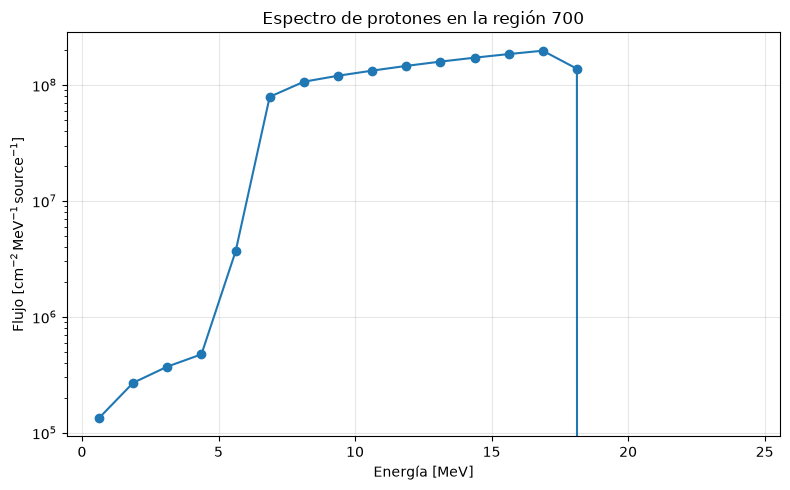

In [6]:
import numpy as np
import matplotlib.pyplot as plt

archivo = "../out/espectro_region3.out"

emin = []
emax = []
flujo = []
error_rel = []

with open(archivo, "r") as f:
    for linea in f:
        partes = linea.split()

        if len(partes) != 4:
            continue

        try:
            e1 = float(partes[0])
            e2 = float(partes[1])
            y = float(partes[2])
            err = float(partes[3])

            emin.append(e1)
            emax.append(e2)
            flujo.append(y)
            error_rel.append(err)

        except ValueError:
            continue

emin = np.array(emin)
emax = np.array(emax)
flujo = np.array(flujo)
error_rel = np.array(error_rel)

energia = (emin + emax) / 2
error_abs = flujo * error_rel

plt.figure(figsize=(8, 5))

plt.errorbar(
    energia,
    flujo,
    yerr=error_abs,
    fmt="o-",
    capsize=3
)

plt.xlabel("Energía [MeV]")
plt.ylabel(r"Flujo [$\mathrm{cm^{-2}\,MeV^{-1}\,source^{-1}}$]")
plt.title("Espectro de protones en la región 700")

plt.yscale("log")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


----------------------------------------
ÚLTIMO BIN CON FLUJO
----------------------------------------
Intervalo: 17.500 - 18.750 MeV
Energía central: 18.125 MeV
Flujo: 1.3786e+08


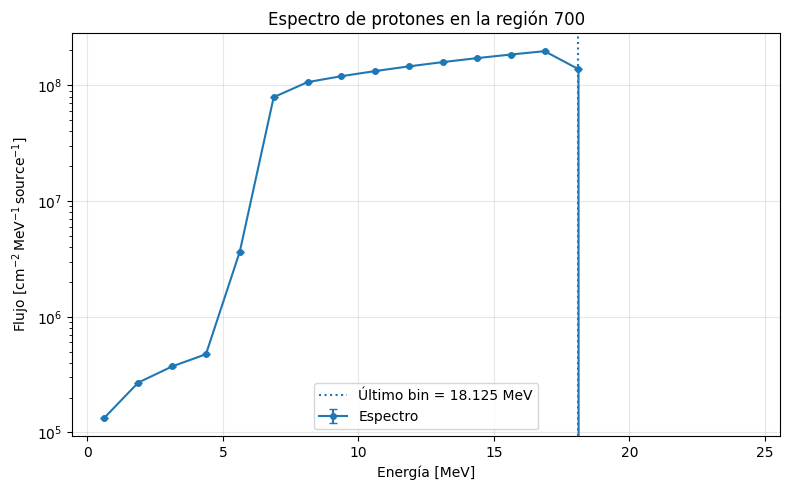

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ARCHIVO
# ============================================================

archivo = "../out/espectro_region3.out"


# ============================================================
# LEER DATOS DEL ESPECTRO
# ============================================================

emin = []
emax = []
flujo = []
error_rel = []

with open(archivo, "r") as f:

    for linea in f:

        partes = linea.split()

        # Nos interesan solamente las líneas:
        # emin   emax   flujo   error
        if len(partes) != 4:
            continue

        try:

            e1 = float(partes[0])
            e2 = float(partes[1])
            y = float(partes[2])
            err = float(partes[3])

            emin.append(e1)
            emax.append(e2)
            flujo.append(y)
            error_rel.append(err)

        except ValueError:
            continue


# Convertir a arrays de numpy

emin = np.array(emin)
emax = np.array(emax)
flujo = np.array(flujo)
error_rel = np.array(error_rel)


# ============================================================
# ENERGÍA CENTRAL DE CADA BIN
# ============================================================

energia = (emin + emax) / 2


# ============================================================
# ERROR ABSOLUTO
# ============================================================

error_abs = flujo * error_rel



# ============================================================
# 2. ÚLTIMO BIN CON FLUJO
# ============================================================

indices = np.where(flujo > 0)[0]

if len(indices) > 0:

    i_ultimo = indices[-1]

    energia_ultimo = energia[i_ultimo]

    print()
    print("----------------------------------------")
    print("ÚLTIMO BIN CON FLUJO")
    print("----------------------------------------")

    print(
        f"Intervalo: "
        f"{emin[i_ultimo]:.3f} - {emax[i_ultimo]:.3f} MeV"
    )

    print(
        f"Energía central: "
        f"{energia_ultimo:.3f} MeV"
    )

    print(
        f"Flujo: "
        f"{flujo[i_ultimo]:.4e}"
    )

else:

    energia_ultimo = None

    print("No hay flujo distinto de cero.")


# ============================================================
# GRÁFICO
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    energia,
    flujo,
    yerr=error_abs,
    fmt="o-",
    markersize=4,
    capsize=3,
    label="Espectro"
)


# ------------------------------------------------------------
# Marcar último bin con flujo
# ------------------------------------------------------------

if energia_ultimo is not None:

    plt.axvline(
        energia_ultimo,
        linestyle=":",
        label=f"Último bin = {energia_ultimo:.3f} MeV"
    )


# ============================================================
# CONFIGURACIÓN DEL GRÁFICO
# ============================================================

plt.xlabel("Energía [MeV]")

plt.ylabel(
    r"Flujo [$\mathrm{cm^{-2}\,MeV^{-1}\,source^{-1}}$]"
)

plt.title("Espectro de protones en la región 700")

plt.yscale("log")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()